# Vẽ biểu đồ từ kết quả grid search (chỉ đọc CSV)

Notebook này **không huấn luyện** — chỉ đọc `models/hyperparam_grid_results.csv` (do `anfis_pca_scikit_anfis_training.ipynb` tạo ra) và vẽ biểu đồ.

Mỗi tỷ lệ **80/20, 70/30, 60/40** xuất **1 file** vào `plots/`:

| File | Nội dung |
|------|----------|
| `plots/hyperparam_accuracy_*.png` | Accuracy (%) theo epoch / learning rate |

Confusion matrix và biểu đồ RMSE cần huấn luyện lại model → xem bước 5 trong notebook training.

**Chạy:** mở CSV có sẵn → chạy các cell bên dưới → PNG trong `plots/`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
})

In [2]:
# --- Cau hinh ---
SPLIT_RATIOS = ["80-20", "70-30", "60-40"]
SPLIT_TITLES = {
    "80-20": "80 - 20% of train-test data",
    "70-30": "70 - 30% of train-test data",
    "60-40": "60 - 40% of train-test data",
}
LEARNING_RATES = [0.001, 0.01, 0.05]
EPOCH_LIST = [25, 50, 75, 100]
LR_COLORS = {0.001: "#f4a261", 0.01: "#8ecae6", 0.05: "#b39ddb"}
LR_LABELS = {0.001: "0.001", 0.01: "0.01", 0.05: "0.05"}

RESULTS_PATH = Path("models") / "hyperparam_grid_results.csv"
OUT_DIR = Path("plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Khong tim thay {RESULTS_PATH}. "
        "Hay chay grid search trong anfis_pca_scikit_anfis_training.ipynb truoc."
    )

grid_df = pd.read_csv(RESULTS_PATH)
print(f"Loaded: {RESULTS_PATH} ({len(grid_df)} rows)")
display(grid_df.sort_values(["split_ratio", "epochs", "learning_rate"]))

Loaded: models\hyperparam_grid_results.csv (36 rows)


,split_ratio,test_size,train_size,test_n,learning_rate,epochs,test_accuracy,test_accuracy_pct
24,60-40,0.4,397,266,0.001,25,0.894737,89.47
28,60-40,0.4,397,266,0.010,25,0.898496,89.85
32,60-40,0.4,397,266,0.050,25,0.860902,86.09
25,60-40,0.4,397,266,0.001,50,0.894737,89.47
29,60-40,0.4,397,266,0.010,50,0.898496,89.85
33,60-40,0.4,397,266,0.050,50,0.842105,84.21
26,60-40,0.4,397,266,0.001,75,0.894737,89.47
30,60-40,0.4,397,266,0.010,75,0.864662,86.47
34,60-40,0.4,397,266,0.050,75,0.853383,85.34
27,60-40,0.4,397,266,0.001,100,0.894737,89.47


In [5]:
def best_config_for_split(df, split_label):
    """lr + epoch co test accuracy cao nhat trong CSV."""
    sub = df[df["split_ratio"] == split_label]
    best = sub.loc[sub["test_accuracy"].idxmax()]
    return float(best["learning_rate"]), int(best["epochs"]), float(best["test_accuracy_pct"])


def plot_grouped_accuracy(df, split_label, ax=None):
    sub = df[df["split_ratio"] == split_label].copy()
    bar_width = 0.22
    x = np.arange(len(EPOCH_LIST))
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5.5))
    else:
        fig = ax.figure
    for i, lr in enumerate(LEARNING_RATES):
        vals = [
            float(sub[(sub["epochs"] == ep) & (sub["learning_rate"] == lr)]["test_accuracy_pct"].iloc[0])
            for ep in EPOCH_LIST
        ]
        offset = (i - (len(LEARNING_RATES) - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset, vals, width=bar_width,
            color=LR_COLORS[lr], label=LR_LABELS[lr], edgecolor="none", alpha=0.92,
        )
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{val:.2f}", ha="center", va="bottom", rotation=90, fontsize=9,
            )
    lr, epochs, best_acc = best_config_for_split(df, split_label)
    ax.set_title(
        f"{SPLIT_TITLES[split_label]}  |  best: lr={lr}, epochs={epochs}, test acc={best_acc:.2f}%",
        fontsize=13, fontweight="bold", pad=12,
    )
    ax.set_xlabel("Epoch at different learning rate", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([str(e) for e in EPOCH_LIST])
    ax.set_ylim(0, 105)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return fig, ax

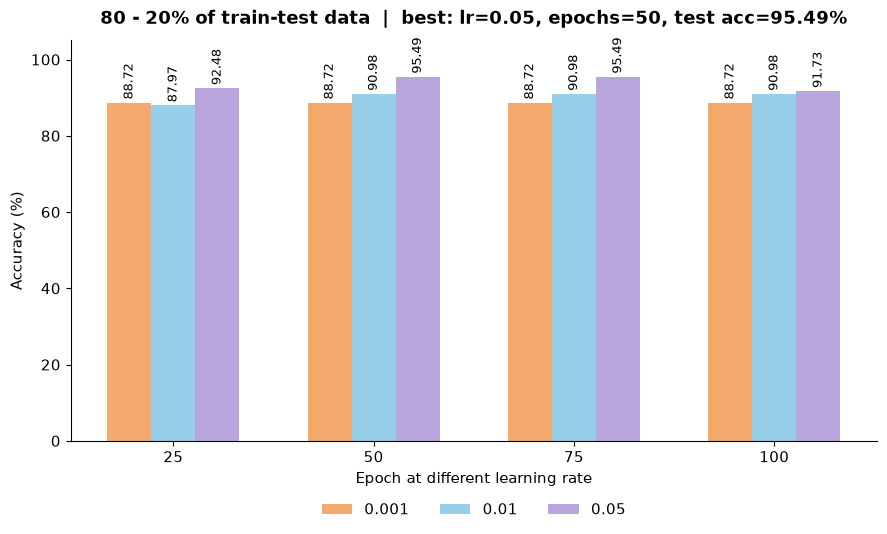

Saved: plots\hyperparam_accuracy_80_20.png  (best lr=0.05, epochs=50, acc=95.49%)


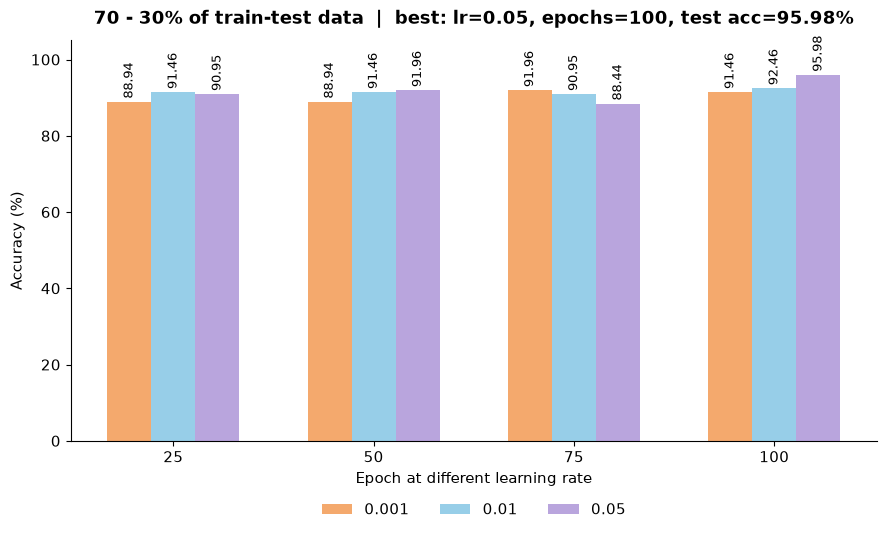

Saved: plots\hyperparam_accuracy_70_30.png  (best lr=0.05, epochs=100, acc=95.98%)


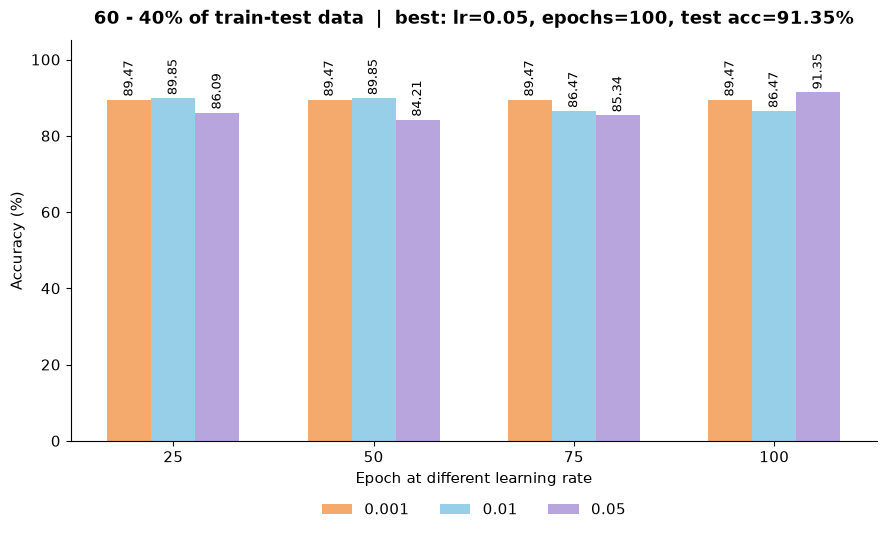

Saved: plots\hyperparam_accuracy_60_40.png  (best lr=0.05, epochs=100, acc=91.35%)


In [6]:
for split_label in SPLIT_RATIOS:
    if split_label not in grid_df["split_ratio"].values:
        print(f"Bo qua {split_label}: khong co trong CSV")
        continue

    fig, _ = plot_grouped_accuracy(grid_df, split_label)
    fig.tight_layout()
    plt.show()

    slug = split_label.replace("-", "_")
    out_path = OUT_DIR / f"hyperparam_accuracy_{slug}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    lr, epochs, best_acc = best_config_for_split(grid_df, split_label)
    print(f"Saved: {out_path}  (best lr={lr}, epochs={epochs}, acc={best_acc:.2f}%)")